In [ ]:
from IPython.core.display import HTML
from IPython.core.pylabtools import figsize
import matplotlib as mpl

figsize(17, 2)
mpl.rcParams['agg.path.chunksize'] = 10000

In [ ]:
import numpy as np
#import scipy.special as sp
from  scipy.constants import c
import matplotlib.pyplot as plt
#!pip install OptiCommPy
from optic.utils import parameters
from optic.dsp.core import firFilter, signal_power, pulseShape, upsample, pnorm
from optic.models.devices import mzm, photodiode
from optic.plot import eyediagram

## Propagação de Pulsos ópticos SSFM.
---

## Sumário
---
- [Introdução](#introdução)
- [Método de solução (Split-Step Fourier - SSF)](#Metodo_de_solução_(Split-Step_Fourier_-_SSF))
- [Transmissão 10G OOK - 40 km](#Transmissão_10G_OOK_-_40_km)

### Introdução
---

Nas fibras ópticas reais, quando a intensidade do sinal óptico (potência) é elevada, como acontece em longas distâncias ou altas taxas de transmissão, os efeitos não lineares do material da fibra passam a se manifestar de forma significativa. Esses efeitos distorcem a forma do pulso durante sua propagação, provocando alargamento temporal, mudança de frequência (chirp) e interferência entre símbolos.

A equação que descreve a propagação de um pulso óptico em uma fibra óptica com coeficiente de perdas igual a $α$, coeficiente GVD $β_2$ e coeficiente não linear $γ$, é chamada de *Equação de Schrödinger não linear generalizada (NLSE)*:

$$\begin{equation}
j\frac{\partial A}{\partial z} + j\frac{\alpha}{2}A -
\frac{\beta_2}{2}\frac{\partial^2 A}{\partial t^2} +
γ|A|^2A = 0
\end{equation}$$

em que $A(z,t)$ é a amplitude do sinal na posição $z$ e tempo $t$. $A_{eff}$ a área efetiva do modo na fibra que varia entre 20-100 $μm^2$ na região 1550nm. Importante lembrar que o parâmetro de dispersão [ps/(km.nm)] é definido como:

$$D = \frac{2\pi c}{λ^2}\beta_2 ⟶
\gamma = \frac{n_2\omega_0}{cA_{eff}} ⟶
A_{eff} = \pi \omega^2
$$

### Método de solução (Split-Step Fourier - SSF)
---

Devido a complexidade da equação de propagação de Schrödinger utilizaremos o o Método de Fourier de Passo Dividido (Split-Step Fourier - SSF), que divide o problema em duas partes que são resolvidas sequencialmente. A parte linear considera somente os efeitos lineares, *dispersão e perdas*, já a parte não linear considera o efeito kerr $γ$.

A equação pode ser expressa da seguinte forma:

$$\begin{equation}
\frac{\partial A}{\partial z} = \left[\hat{D} + \hat{N}\right]A
\end{equation}$$, onde:

$$\begin{equation}
\hat{D} = -i\frac{\beta_2}{2}\frac{\partial^2}{\partial t^2} - \frac{\alpha}{2}  \\
\hat{N} = iγ |A|^2
\end{equation}$$

Determinamos $\hat{D}$ como operador linear e $\hat{N}$ como operador não linear. A solução aproximada é:

$$\begin{equation}
A(z + h , t) \approx A(z,t)e^{h\hat{D}}e^{h\hat{N}}
\end{equation}$$
Que pode ser melhor descrito pelo diagrama abaixo, onde é uma aproximação de primeira ordem com erro proporcional a $h^2$  :

<center><img src="https://github.com/edsonportosilva/OpticalCommunications/blob/main/jupyter%20notebooks/figuras/SSF_non_symmetric.png?raw=true" width="40%"/></center>
<center>Fonte: GitHub Edson Porto</center>

In [ ]:
def SSF_Asimetrico(E, h, Lfibra, alpha, gamma, D, Fc, Fs):
    lmbd  = c/Fc
    alpha  = 1e-3*alpha/(10*np.log10(np.exp(1)))
    beta2 = -(D*lmbd**2)/(2*np.pi*c)

    Nfft = len(E)
    ω = 2*np.pi*Fs*np.fft.fftfreq(Nfft)

    z = 0
    while z <= Lfibra:
        # Operador linear
        E = np.fft.fft(E)
        E = E*np.exp(-alpha*h+1j*(beta2/2)*(ω**2)*h)

        # Operador não linear
        E = np.fft.ifft(E)
        E = E*np.exp(1j*gamma*(np.abs(E)**2)*h)

        z += h
    return E,z

def GaussPulse(a0, t0, t):      # Expressão do pulso Gaussiano
  return a0*np.exp(-0.5*(t/t0)**2)

def FGaussPulse(a0, t0, freq):  # Transformada de Fourier do pulso Gaussiano (analítica)
  return a0*t0*np.sqrt(2*np.pi)*np.exp(-0.5*(2*np.pi*freq*t0)**2)

In [ ]:
Lfibra = 10e3  # tamanho da fibra m
h    = 0.1e2   # comprimento de cada interação m
alpha = 0.2    # dB/km
gamma = 1.3e-3 # W-1/m
D  = 16e-10     # s/(m*m)
Fc = 193.1e12  # Hz
Fs = 64e9      # Hz
P0 = 1e-3      # W

t0 = 0.1
fs = 80                         # Taxa de amostragem
t  = np.arange(-0.5,0.5,1/fs)   # Duração da janela do pulso
E  = GaussPulse(np.sqrt(P0), t0, t)

E_out, z  = SSF_Asimetrico(E, h, Lfibra, alpha, gamma, D, Fc, Fs)
alpha_lin = 1e-3*alpha/(10*np.log10(np.exp(1)))
E_rx = E_out*np.exp(alpha_lin * z)
delta_w = -np.diff(np.angle(E_rx))/(t[1]-t[0])

z = 10.010000 km


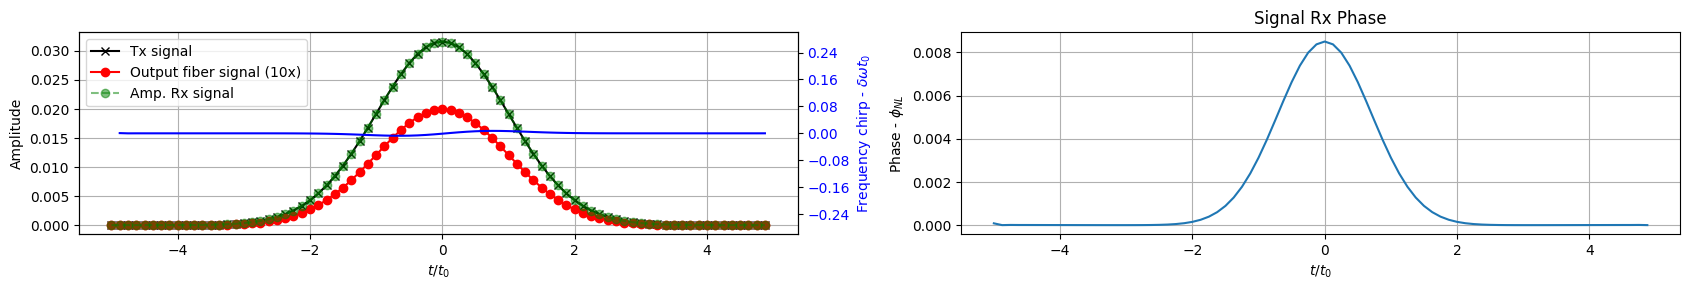

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(17,3))
axs[0].plot(t/t0, np.abs(E),     'kx-',  label = 'Tx signal')
axs[0].plot(t/t0, np.abs(E_out), 'ro-',  label = 'Output fiber signal (10x)')
axs[0].plot(t/t0, np.abs(E_rx),  'go--', label = 'Amp. Rx signal', alpha = 0.5)
axs[0].set_xlabel(r'$t/t_0$')
axs[0].set_ylabel('Amplitude')
#axs[0].set_ylim([0,0.2])
axs[0].legend(loc = 'upper left')
axs[0].grid(True)

axs1 = axs[0].twinx()
axs1.plot(t[1:]/t0, t0*delta_w, 'blue')
axs1.set_ylabel('Frequency chirp - $\delta \omega t_0$', color = 'blue')
axs1.tick_params(axis='y', labelcolor='blue')
axs1.set_ylim([-.3,.3])
axs1.yaxis.set_major_locator(plt.MaxNLocator(9))

axs[1].plot(t/t0, np.angle(E_rx))
axs[1].set_xlabel(r'$t/t_0$')
axs[1].set_ylabel('Phase - $\phi_{NL}$')
axs[1].set_title('Signal Rx Phase')
axs[1].grid(True)
print('z = %f km' %(1e-3*z))

fig.tight_layout()

  O modo SSF simétrico vem da estrutura simétrica da aproximação matemática, Erro de segunda ordem, ou seja, muito mais preciso (erro proporcional a $h^3$)

$$\begin{equation}
A(z + h , t) \approx A(z,t)e^{\frac{h}{2}\hat{D}}e^{h\hat{N}}e^{\frac{h}{2}\hat{D}}
\end{equation}$$

In [ ]:
def SSF_simetrico(E, h, Lfibra, alpha, gamma, D, Fc, Fs):
    lmbd  = c/Fc
    alpha  = 1e-3*alpha/(10*np.log10(np.exp(1)))
    beta2 = -(D*lmbd**2)/(2*np.pi*c)

    Nfft = len(E)
    ω = 2*np.pi*Fs*np.fft.fftfreq(Nfft)
    z = 0

    E = np.fft.fft(E)
    while z <= Lfibra:
        # Primeiro passo - operador linear
        E = E*np.exp(-alpha*(h/2)+1j*(beta2/2)*(ω**2)*(h/2))

        # Operador não linear
        E = np.fft.ifft(E)
        E = E*np.exp(1j*gamma*(np.abs(E)**2)*h)

        # Primeiro passo - operador linear
        E = np.fft.fft(E)
        E = E*np.exp(-alpha*(h/2)+1j*(beta2/2)*(ω**2)*(h/2))

        z += h
    E = np.fft.ifft(E)
    return E,z

z = 10.010000 km


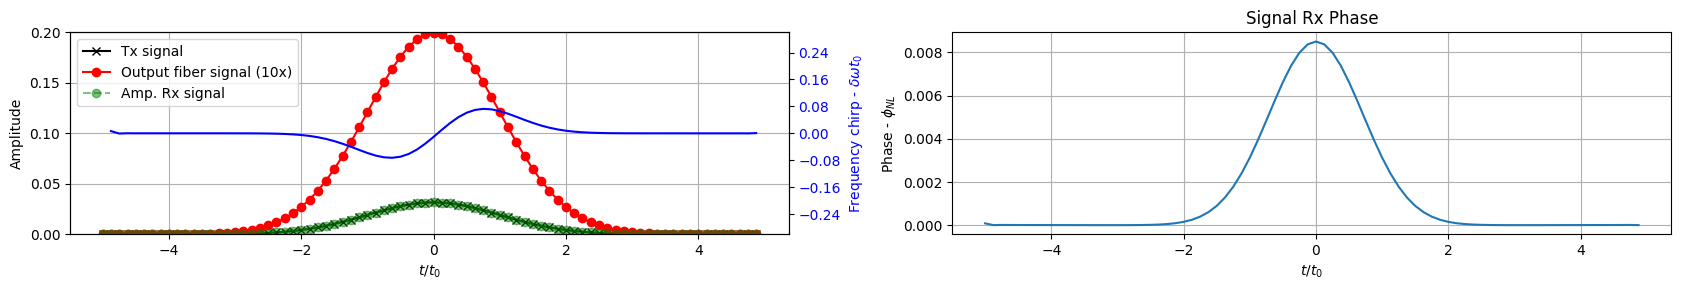

In [ ]:
Nspan   = 10 #1000 km total
E_amp_i = E
for _ in range(Nspan):
    E_out_i, z = SSF_simetrico(E_amp_i, h, Lfibra, alpha, gamma, D, Fc, Fs)
    E_amp_i    = E_out_i*np.exp(alpha_lin * z)
delta_w = -np.diff(np.angle(E_amp_i))/(t[1]-t[0])

fig, axs = plt.subplots(1, 2, figsize=(17,3))
axs[0].plot(t/t0,    np.abs(E),     'kx-',  label = 'Tx signal')
axs[0].plot(t/t0, 10*np.abs(E_out), 'ro-',  label = 'Output fiber signal (10x)')
axs[0].plot(t/t0,    np.abs(E_rx),  'go--', label = 'Amp. Rx signal', alpha = 0.5)
axs[0].set_xlabel(r'$t/t_0$')
axs[0].set_ylabel('Amplitude')
axs[0].set_ylim([0,0.2])
axs[0].legend(loc = 'upper left')
axs[0].grid(True)

axs1 = axs[0].twinx()
axs1.plot(t[1:]/t0, t0*delta_w, 'blue')
axs1.set_ylabel('Frequency chirp - $\delta \omega t_0$', color = 'blue')
axs1.tick_params(axis='y', labelcolor='blue')
axs1.set_ylim([-.30,.30])
axs1.yaxis.set_major_locator(plt.MaxNLocator(9))

axs[1].plot(t/t0, np.angle(E_rx))
axs[1].set_xlabel(r'$t/t_0$')
axs[1].set_ylabel('Phase - $\phi_{NL}$')
axs[1].set_title('Signal Rx Phase')
axs[1].grid(True)
print('z = %f km' %(1e-3*z))

fig.tight_layout()

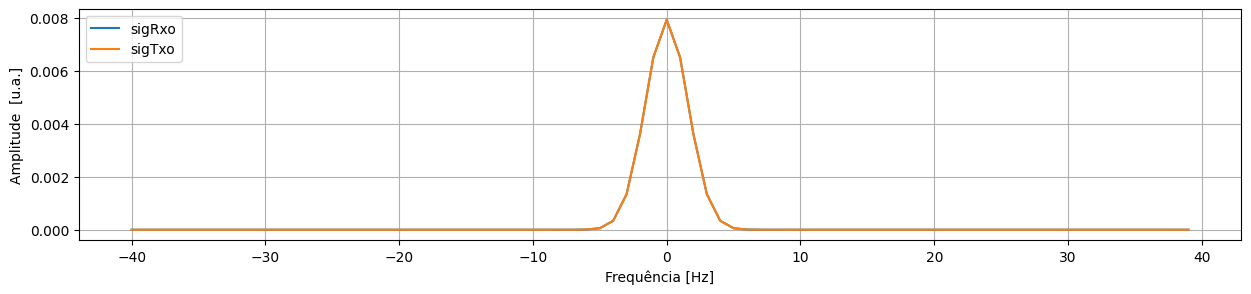

In [ ]:
NFFT = len(E_rx)
f    = fs/NFFT * np.arange(-NFFT/2,NFFT/2)
Xa   = FGaussPulse(np.sqrt(P0), t0, f)             # Trasnformada de Fourier do pulso transmitido
E_rx_FFT = np.fft.fftshift(np.fft.fft(E_rx, NFFT)) # Transformada de Fourier do pulso recebido

fig =plt.figure(figsize=(15,3))
plt.plot(f, abs(E_rx_FFT)/NFFT, label = 'sigRxo')
plt.plot(f, Xa, label = 'sigTxo')
plt.xlabel('Frequência [Hz]')
plt.ylabel('Amplitude  [u.a.]')
plt.grid(True)
plt.legend(loc = 'upper left')
plt.show()

### Transmissão 10G OOK - 40 km
---


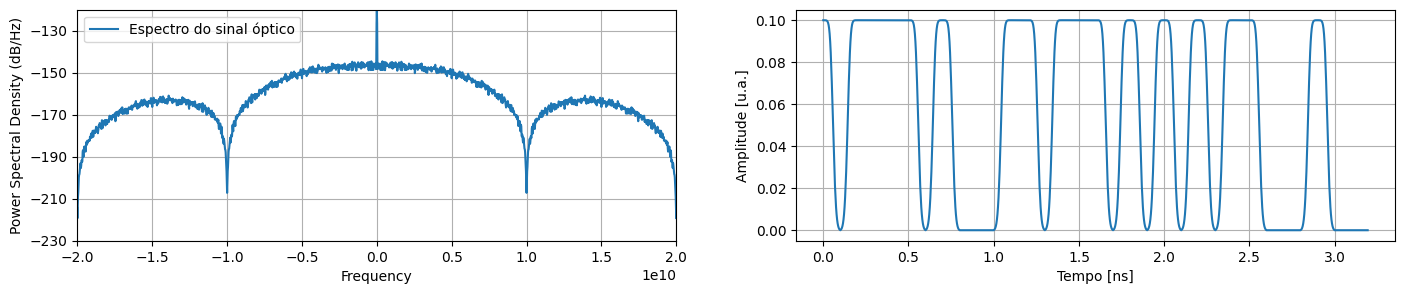

In [ ]:
# parâmetros da simulação
SpS = 32
Rs  = 10e9          # Taxa de símbolos (para o caso do OOK Rs = Rb)
Ts  = 1/Rs          # Período de símbolo em segundos
Fa  = 1/(Ts/SpS)    # Frequência de amostragem do sinal (amostras/segundo)
Ta  = 1/Fa          # Período de amostragem

# Parâmetros do sinal
lmbd   = 1550e-9       # comprimento de onda
Pi_dBm = 10            # potência de sinal óptico na entrada do modulador em dBm

# Parâmetros do MZM
paramMZM = parameters()
paramMZM.Vpi = 2
paramMZM.Vb = (-paramMZM.Vpi/2)
Pi =  10**(Pi_dBm/10)*1e-3

# Parâmetros da fibra
alpha = 0.16   # dB/Km
D     = 18e-6  # Parâmetro de dispersão s/(m*m) - SMF28 (ps/(nm*km))
gamma = 4*1.3e-3 # W-1/m
Lspan = 40e3   # Comprimento do enlace m
hz    = 0.1e3  # m

# Parâmetros do receptor
Rd  = 0.85      # responsividade em A/W

# gera sequência de bits pseudo-aleatórios
bits   = np.random.randint(2, size=10000)
n      = np.arange(0, bits.size)

# mapeia bits para pulsos elétricos
symb = 2*bits-1
symb = symb/np.sqrt(signal_power(symb))

# upsampling
symbolsUp = upsample(symb, SpS)

# pulso NRZ típico
pulse = pulseShape("nrz", SpS)
pulse = pulse/max(abs(pulse))

# plota sinal
t = np.arange(0, symb.size)*(Ta/1e-9)

#idX = np.arange(0,513)
idX = np.arange(0,1023)
# formatação de pulso
sigft  = firFilter(pulse, symbolsUp)

# modulação óptica
Ai     = np.sqrt(Pi)
sigfto = mzm(Ai, -(paramMZM.Vb)*sigft, paramMZM)

# plota psd
fig, axs = plt.subplots(1, 2, figsize=(17,3))
axs[0].set_xlim(-2*Rs,2*Rs);
axs[0].set_ylim(-230,-120);
axs[0].psd(np.abs(sigfto)**2,Fs=Fa, NFFT = 16*1024, sides='twosided', label = 'Espectro do sinal óptico')
axs[0].legend(loc='upper left')

axs[1].plot(t[idX], np.abs(sigfto[idX]))
axs[1].set_xlabel('Tempo [ns]')
axs[1].set_ylabel('Amplitude [u.a.]')
axs[1].grid(True)

Potência do sinal Tx (em dBm) = 7.03 dBm
Potência do sinal Rx (em dBm) = 7.03 dBm


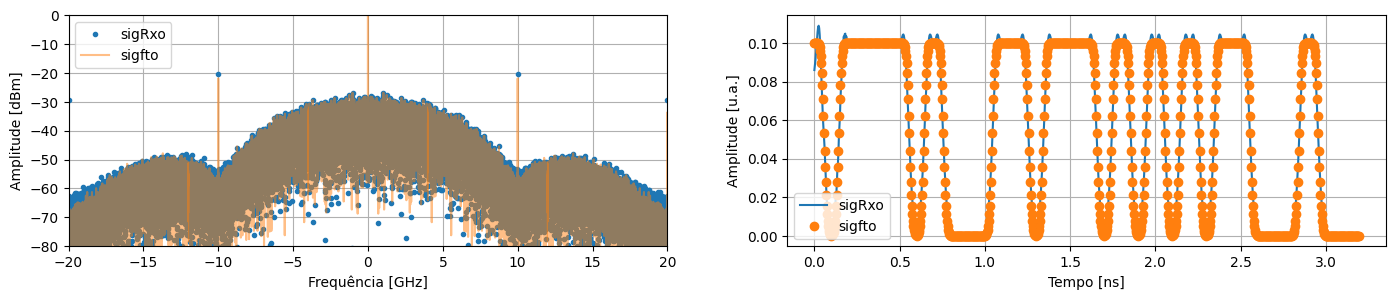

In [ ]:
# transmissão óptica
NFFT = len(sigfto)
sigftoFFT = np.fft.fftshift(np.fft.fft(sigfto))/NFFT
sigftoPx  = np.abs(sigftoFFT)**2
freq = np.fft.fftshift(np.fft.fftfreq(len(sigftoFFT), Ta))

# Fibra óptica
sigRxo, z = SSF_simetrico(sigfto, h, Lfibra, alpha, gamma, D, Fc, Fa) # Propagation

alpha_lin = 1e-3*alpha/(10*np.log10(np.exp(1)))
sigRxo    = sigRxo*np.exp(alpha_lin * z)                             # Amplification

sigRxoFFT = np.fft.fftshift(np.fft.fft(sigRxo))/NFFT
sigRxoPx  = np.abs(sigRxoFFT)**2

fig, axs = plt.subplots(1, 2, figsize=(17,3))
axs[0].plot(1e-9*freq, 10*np.log10(1e3*sigRxoPx), ".", label = "sigRxo")
axs[0].plot(1e-9*freq, 10*np.log10(1e3*sigftoPx), alpha = 0.5, label = "sigfto")
axs[0].set_ylabel("Amplitude [dBm]")
axs[0].set_xlabel("Frequência [GHz]")
axs[0].set_xlim(-2e-9*Rs,2e-9*Rs)
axs[0].set_ylim(-80,0)
axs[0].grid(True)
axs[0].legend(loc = "upper left")

axs[1].plot(t[:1023], np.abs(sigRxo[:1023]), label = "sigRxo")
axs[1].plot(t[:1023], np.abs(sigfto[:1023]), "o", label = "sigfto", alpha = 0.5)
axs[1].set_xlabel("Tempo [ns]")
axs[1].set_ylabel("Amplitude [u.a.]")
axs[1].grid(True)
axs[1].legend(loc = "lower left")

print("Potência do sinal Tx (em dBm) = %.2f dBm" %(10*np.log10(np.sum(sigftoPx)/1e-3)))
print("Potência do sinal Rx (em dBm) = %.2f dBm" %(10*np.log10(np.sum(sigRxoPx)/1e-3)))


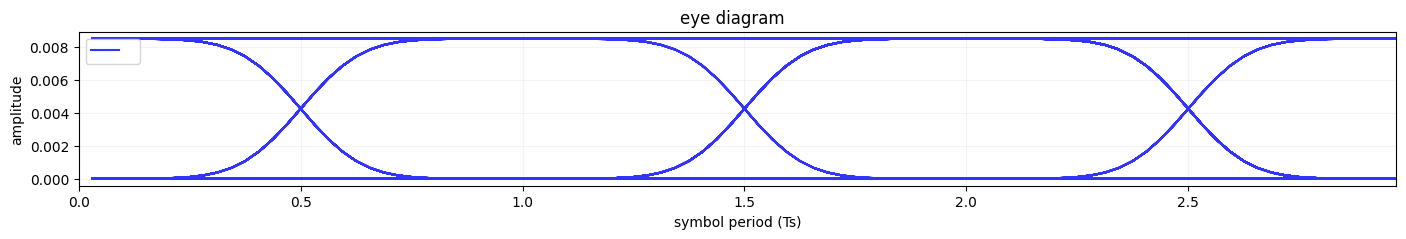

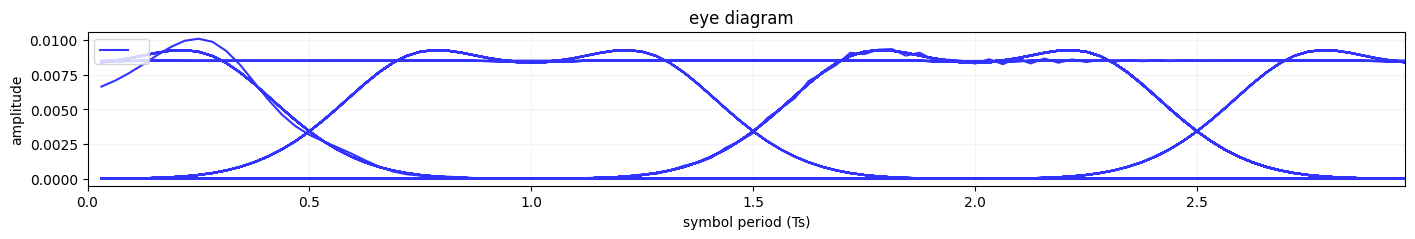

In [ ]:
# Recepção do sinal óptico
Nsamples = 2**12

# fotocorrente livre de ruído
Ip   = Rd*np.abs(sigfto)**2
I_Rx = Rd*np.abs(sigRxo)**2

# diagrama de olho
eyediagram(Ip,  Nsamples, SpS)
eyediagram(I_Rx, Nsamples, SpS)

### Referências
---
1.**OpticalCommunications**. *Edson porto da Silva*. Disponível em: [https://github.com/edsonportosilva/OpticalCommunications/...notebooks](https://github.com/edsonportosilva/OpticalCommunications/tree/main/jupyter%20notebooks). Acessado em: 16 de junho de 2025.